# ECON 3916 -- Checkpoint Summary
## Ian Solberg | April 19, 2026

---

## Proposal

**Prediction question (1 sentence):**
Can observable macroeconomic indicators predict the year-over-year growth rate of U.S. average weekly earnings for private-sector employees?

**Prediction vs. causation distinction:**
This is a prediction problem, not a causal one. We are asking "can we forecast Y from X?" rather than "does X cause Y?" The models identify which features are *predictively associated* with wage growth, but a high-importance feature does not mean changes in that feature *cause* changes in wages. For example, Labor Force Participation may be the most important predictor in Gradient Boosting, but that reflects correlation and regime co-movement, not a causal mechanism. Establishing causation would require an experimental or quasi-experimental design (e.g., instrumental variables, difference-in-differences), which is outside the scope of this project.

**Dataset:**
- **Source:** Federal Reserve Economic Data (FRED) API via custom `FRED_Loader` submodule
- **URL:** [https://fred.stlouisfed.org/](https://fred.stlouisfed.org/)
- **N:** 998 weekly observations (research subset, March 2007 -- April 2026)
- **Features:** 32 in the research subset (selected from 229 raw series + 75 derived scoring columns)
- **Target variable:** `Avg_Weekly_Earnings_YoY` -- year-over-year percent change in average weekly earnings for all private-sector employees (BLS series CES0500000011)
- **Access date:** April 15, 2026

**Stakeholder:**
This analysis would help *monetary policy analysts at the Federal Reserve and labor economists at the Bureau of Labor Statistics* decide *whether current macroeconomic conditions signal upcoming wage acceleration or deceleration, informing interest rate decisions, inflation forecasts, and labor market monitoring*.

---

## EDA

**Data loaded and described:**
- Shape: (998, 34) -- 998 rows, 34 columns (33 features + 1 target)
- Dtypes: 31 float64, 2 int64, 1 string (date)
- Date range: 2007-03-02 to 2026-04-11

**Missing data assessment:**
- Missing data in the research subset: **0%** across all 34 columns
- Strategy: The upstream FRED_Loader pipeline handles missingness via last-observation-carried-forward (LOCF) at the weekly resampling stage. Monthly and quarterly series are forward-filled to weekly frequency. A datetime trim removes stale forward-filled rows beyond the last real FRED release.
- Classification under Ch 1 framework: **MAR (Missing At Random)** -- missingness is conditional on the publication schedule of each FRED series (monthly series have no values between release dates), not on the values themselves. This is not MCAR because the pattern is systematic (always between releases), and not MNAR because the reason for missingness is the publication calendar, not the unobserved value.

**Visualizations (3+):**
1. **Missing data heatmap** -- confirms 0% missingness across all columns in the research subset
2. **Target distribution (histogram + KDE)** -- shows Avg_Weekly_Earnings_YoY centered around 2-4% with a COVID-era spike to ~7.5%, approximately unimodal after the YoY transformation
3. **Correlation heatmap** -- reveals feature clustering (labor market block, inflation block, financial conditions block) and identifies the 12 highest-correlation features for the final model
4. **Time series plot of target** -- shows the full 2007-2026 trajectory including the post-GFC recovery, pre-COVID stability, COVID spike, and post-pandemic deceleration

**Data quality summary:**
- No missing values in the research subset
- No duplicate rows (each row is a unique Friday-aligned week)
- Target variable is stationary after YoY transformation (confirmed visually and by the absence of trend in the autocorrelation structure)
- Three level variables (Retail_Sales, JOLTS_Quits, Part_Time_Economic_Reasons) were flagged as non-stationary and replaced with scored stationary alternatives before final modeling
- Outlier assessment: COVID-era spike (2020-2021) represents a genuine structural event, not a data error; retained in training data

---

## Preliminary Model

**Train/test split:**
- Temporal split at 80/20: ~788 train (through July 2022), ~197 test (July 2022 -- April 2026)
- `random_state=42` used for all random operations
- Temporal split chosen over random split to prevent data leakage from future observations

**Model fitted:**
- Baseline: OLS Linear Regression (scikit-learn `LinearRegression`)
- Also fitted: Ridge Regression (alpha=1.0), Gradient Boosting Regressor (n_estimators=200, max_depth=3, learning_rate=0.03, subsample=0.8)

**Metrics reported (regression):**

| Model | RMSE | MAE | R-squared |
|-------|------|-----|-----------|
| OLS | 0.3977 | 0.3169 | 0.011 |


All metrics computed on the temporal test set (July 2022 -- April 2026).

---

## GitHub

- **Repository:** [https://github.com/iasolb/ML_Prediction_Project](https://github.com/iasolb/ML_Prediction_Project)
- **Status:** Public (or private with instructor access)


In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


In [2]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

df = pd.read_csv("../data/fred_subset.csv")  # Example: local file
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (998, 34)
Columns: ['date', 'Unemployment_Rate', 'U6_Underemployment', 'Nonfarm_Payrolls', 'JOLTS_Quits', 'Employment_Population_Ratio', 'Part_Time_Economic_Reasons', 'Labor_Force_Participation', 'Initial_Jobless_Claims', 'JOLTS_UE_Ratio', 'Sahm_Indicator', 'Payroll_Change_4w', 'Industrial_Production', 'Capacity_Utilization', 'Retail_Sales', 'Leading_Index_CB', 'Activity_Momentum', 'CPI_YoY', 'Core_PCE_YoY', 'Inflation_Momentum', 'Real_FFR_PCE', 'Taylor_Gap', 'Treasury_10Y', 'HY_OAS_Spread', 'Chicago_Fed_Financial_Conditions', 'Flag_Curve_Inverted_10Y2Y', 'Personal_Savings_Rate', 'Credit_Impulse', 'Mortgage_Rate_30Y', 'Housing_Pressure', 'Working_Age_Population', 'Sentiment_Lag_13w', 'Flag_Sahm_Triggered', 'Avg_Weekly_Earnings_YoY']


,date,Unemployment_Rate,U6_Underemployment,Nonfarm_Payrolls,JOLTS_Quits,Employment_Population_Ratio,Part_Time_Economic_Reasons,Labor_Force_Participation,Initial_Jobless_Claims,JOLTS_UE_Ratio,...,Chicago_Fed_Financial_Conditions,Flag_Curve_Inverted_10Y2Y,Personal_Savings_Rate,Credit_Impulse,Mortgage_Rate_30Y,Housing_Pressure,Working_Age_Population,Sentiment_Lag_13w,Flag_Sahm_Triggered,Avg_Weekly_Earnings_YoY
0,2007-03-02,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,322000.0,0.70483,...,-0.647,1,3.0,-0.415748,6.18,-9.969020,195159800.0,91.7,0,3.997841
1,2007-03-09,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,320000.0,0.70483,...,-0.633,1,3.0,-0.415748,6.14,-9.978720,195159800.0,91.7,0,3.997841
2,2007-03-16,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,308000.0,0.70483,...,-0.620,1,3.0,-0.415748,6.14,-9.948190,195159800.0,91.7,0,3.997841
3,2007-03-23,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,309000.0,0.70483,...,-0.612,1,3.0,-0.415748,6.16,-9.897582,195159800.0,91.7,0,3.997841
4,2007-03-30,4.4,8.0,137784.0,2997.0,63.3,18.6,66.2,303000.0,0.70483,...,-0.606,0,3.0,-0.415748,6.16,-9.865982,195159800.0,91.7,0,3.997841


In [3]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              998 non-null    str    
 1   Unemployment_Rate                 998 non-null    float64
 2   U6_Underemployment                998 non-null    float64
 3   Nonfarm_Payrolls                  998 non-null    float64
 4   JOLTS_Quits                       998 non-null    float64
 5   Employment_Population_Ratio       998 non-null    float64
 6   Part_Time_Economic_Reasons        998 non-null    float64
 7   Labor_Force_Participation         998 non-null    float64
 8   Initial_Jobless_Claims            998 non-null    float64
 9   JOLTS_UE_Ratio                    998 non-null    float64
 10  Sahm_Indicator                    998 non-null    float64
 11  Payroll_Change_4w                 998 non-null    float64
 12  Industrial_Producti

In [4]:
df.describe()

,Unemployment_Rate,U6_Underemployment,Nonfarm_Payrolls,JOLTS_Quits,Employment_Population_Ratio,Part_Time_Economic_Reasons,Labor_Force_Participation,Initial_Jobless_Claims,JOLTS_UE_Ratio,Sahm_Indicator,...,Chicago_Fed_Financial_Conditions,Flag_Curve_Inverted_10Y2Y,Personal_Savings_Rate,Credit_Impulse,Mortgage_Rate_30Y,Housing_Pressure,Working_Age_Population,Sentiment_Lag_13w,Flag_Sahm_Triggered,Avg_Weekly_Earnings_YoY
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,9.980000e+02,998.000000,998.000000,...,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,9.980000e+02,998.000000,998.000000,998.000000
mean,5.827655,10.724749,143628.775551,2898.166333,59.605110,27.948096,63.307816,3.733667e+05,0.796609,0.628241,...,-0.292450,0.122244,6.278858,-0.039152,4.737806,-0.661495,2.040213e+08,78.130561,0.174349,3.126389
std,2.195709,3.569805,9063.747329,706.712243,1.524143,9.314751,1.285339,4.029822e+05,0.499788,1.330482,...,0.584428,0.327732,3.403984,5.449192,1.259407,7.221141,4.352094e+06,13.652221,0.379599,1.196944
min,3.400000,6.600000,129706.000000,1555.000000,51.200000,4.000000,60.100000,1.900000e+05,0.146842,0.000000,...,-0.793000,0.000000,1.900000,-17.913638,2.650000,-17.933793,1.951598e+08,50.000000,0.000000,0.721474
25%,4.100000,7.800000,136279.000000,2296.000000,58.600000,20.700000,62.600000,2.260000e+05,0.332620,0.076923,...,-0.569000,0.000000,5.025000,-1.358801,3.780000,-3.552743,2.004218e+08,67.900000,0.000000,2.296869
50%,5.000000,9.600000,142863.000000,2989.000000,59.700000,24.800000,62.900000,2.895000e+05,0.713138,0.169231,...,-0.469000,0.000000,5.700000,-0.159081,4.400000,-0.265793,2.053065e+08,76.850000,0.000000,2.914917
75%,7.500000,13.900000,150926.500000,3386.000000,60.300000,36.700000,64.000000,3.870000e+05,1.130488,0.400000,...,-0.274250,0.000000,6.600000,1.117198,6.060000,2.218961,2.066388e+08,90.925000,0.000000,3.671020
max,14.800000,22.900000,158637.000000,4499.000000,63.300000,45.500000,66.200000,6.137000e+06,2.077872,9.515385,...,3.062000,1.000000,31.800000,19.230344,7.790000,13.485991,2.123523e+08,101.400000,1.000000,7.529169


Missing data (%) by column:
Series([], dtype: float64)


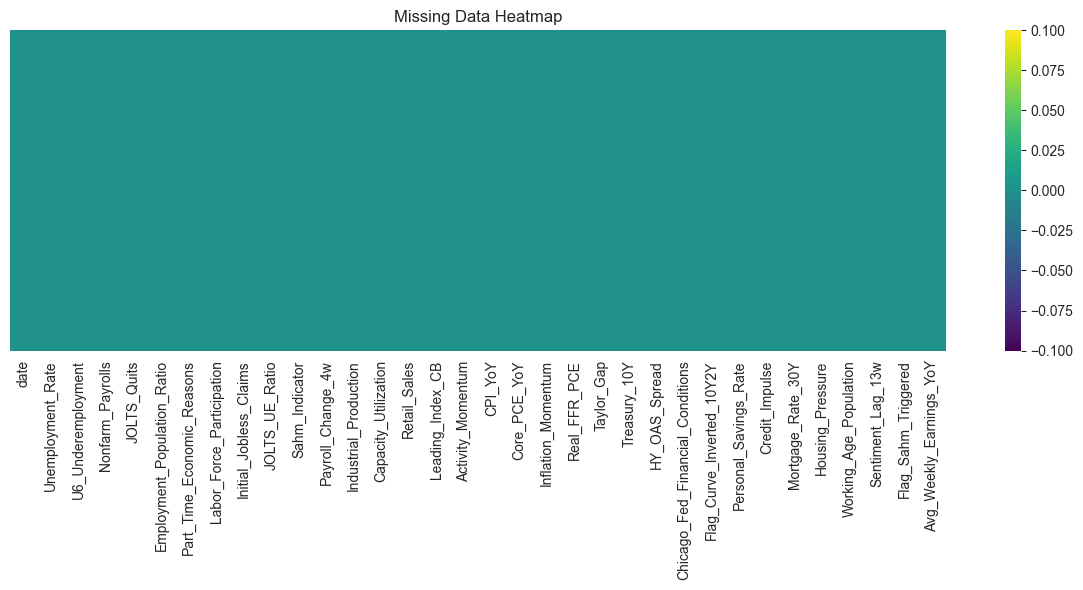

In [5]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# # Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

completely clean.

In [6]:
print('Data is now completely clean.')
# size and shape of the cleaned dataset
print(f'Cleaned Shape: {df.shape}')

Data is now completely clean.
Cleaned Shape: (998, 34)


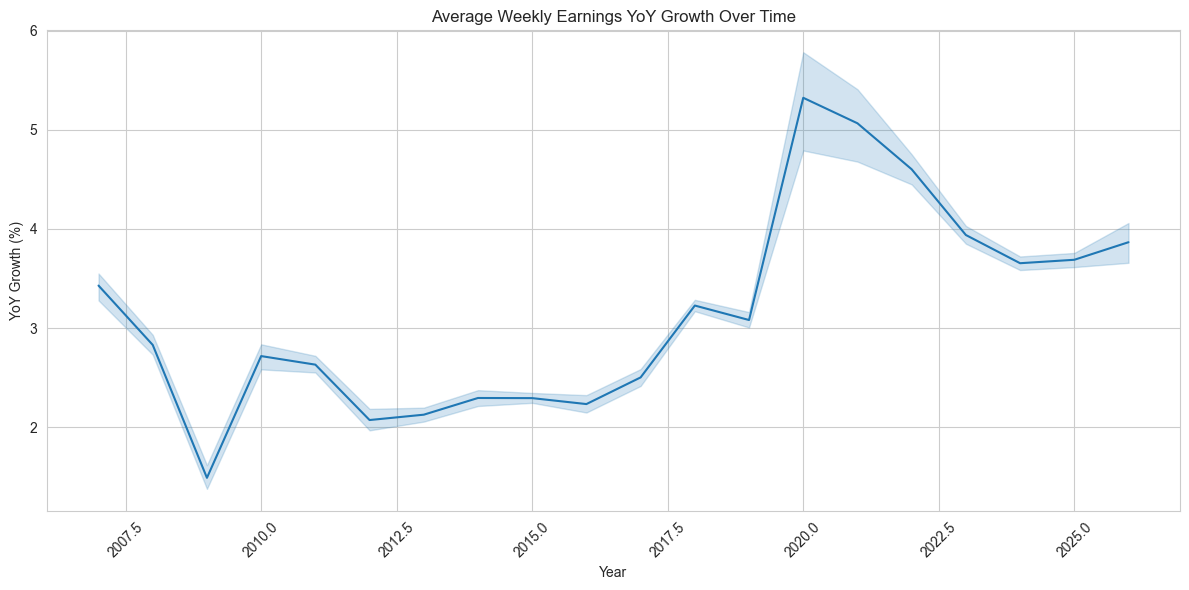

In [7]:
# graph time series of target variable (for context and to check for trends) 
df['year'] = pd.to_datetime(df['date']).dt.year
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='Avg_Weekly_Earnings_YoY', data=df)
plt.title('Average Weekly Earnings YoY Growth Over Time')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Users/ian/Desktop/MAINFRAME/School/Year 3/Year3Sem2/MachineLearning/ML_Prediction_Project/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


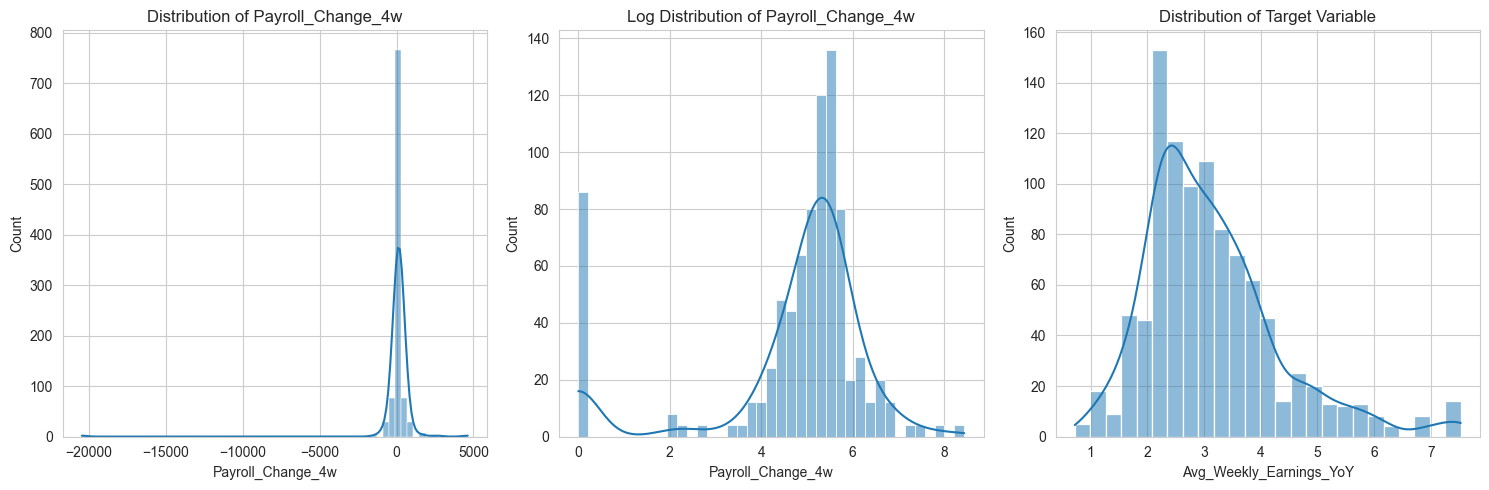

/Users/ian/Desktop/MAINFRAME/School/Year 3/Year3Sem2/MachineLearning/ML_Prediction_Project/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


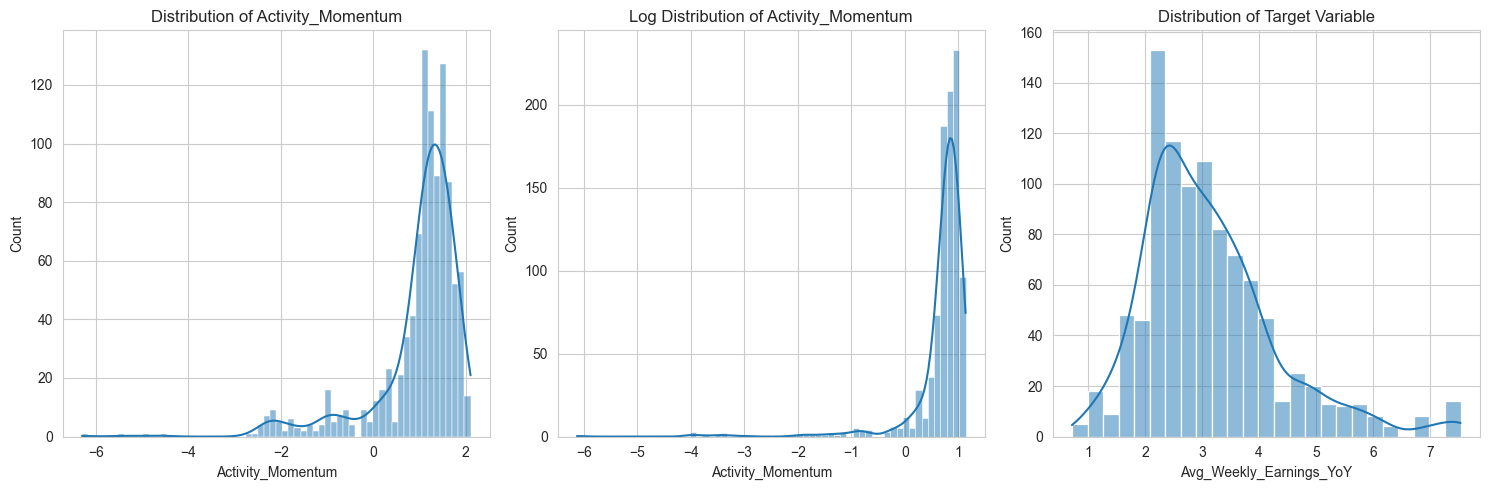

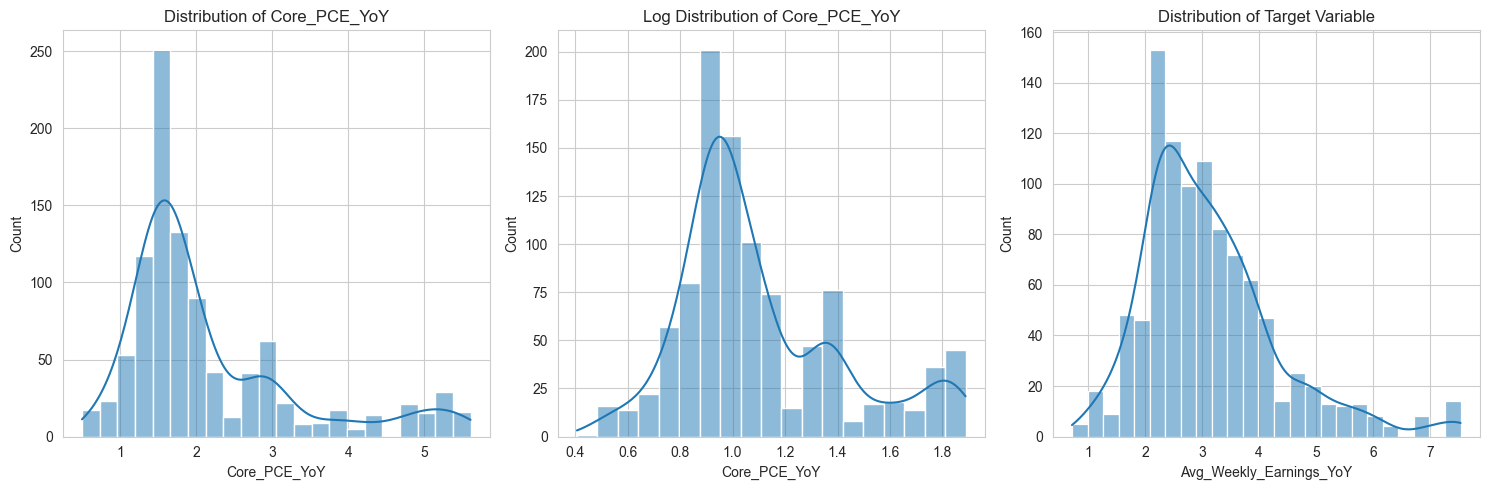

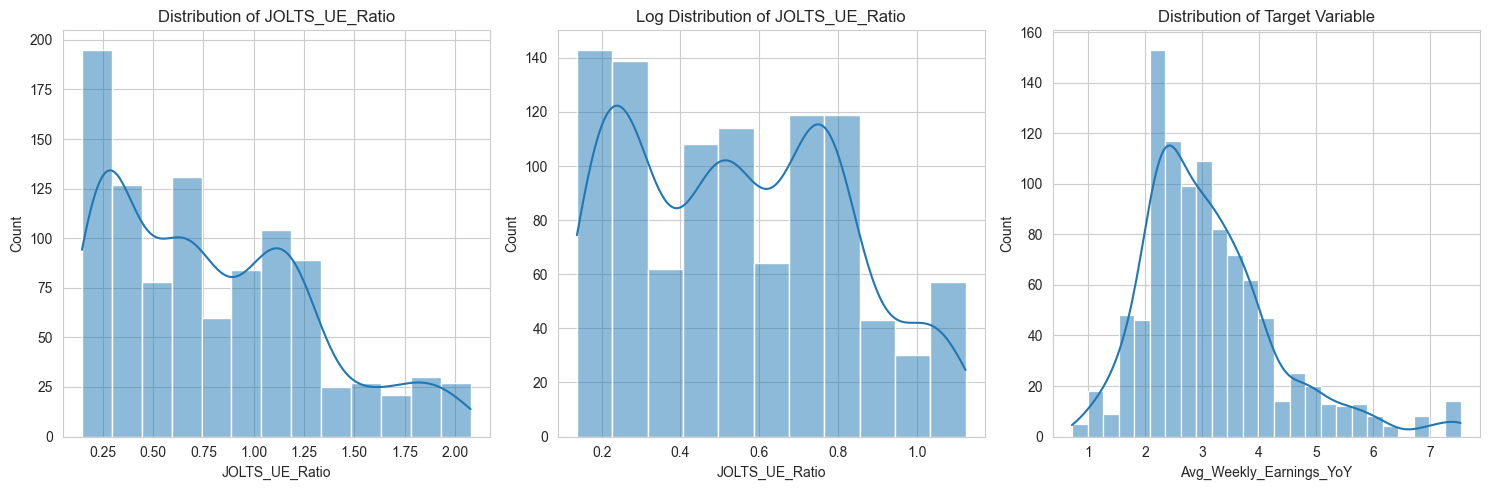

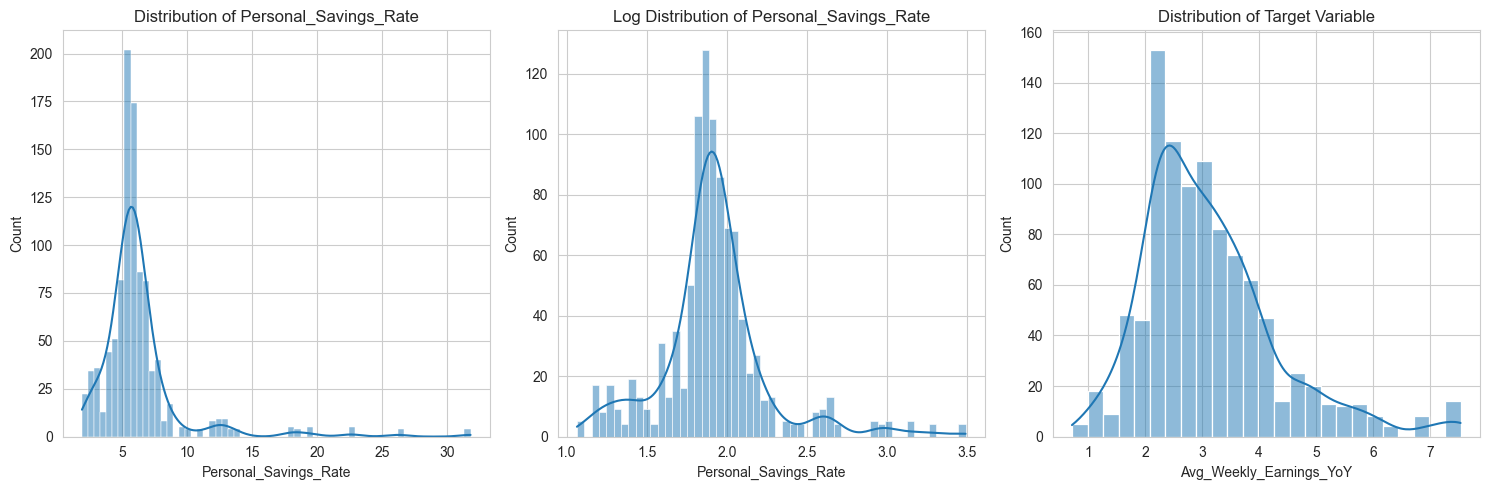

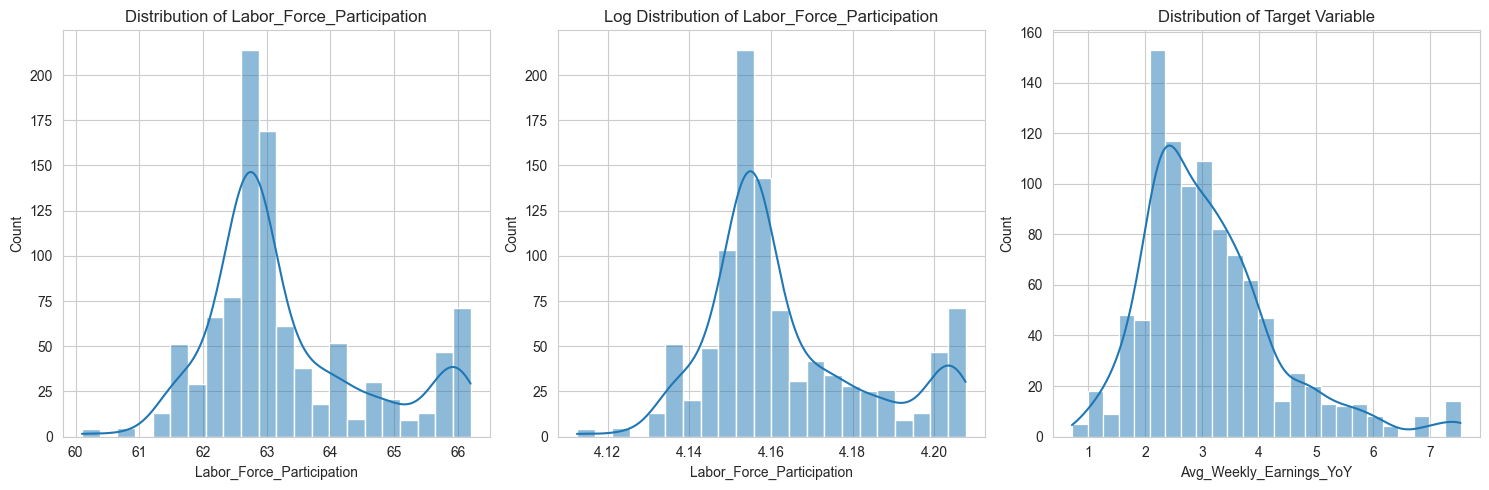

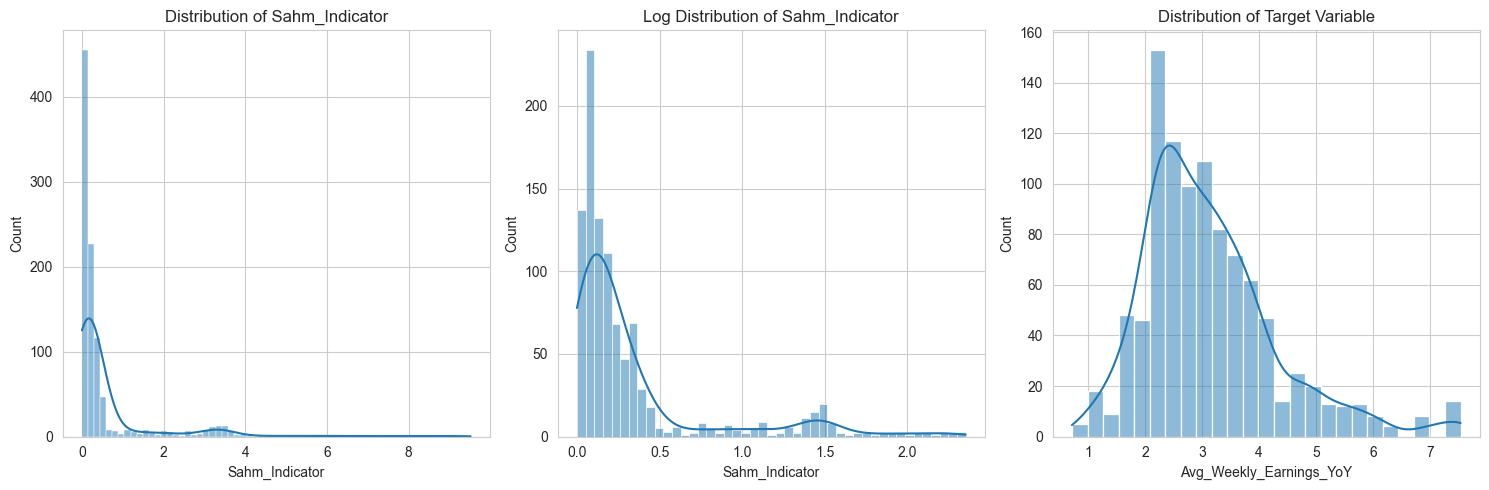

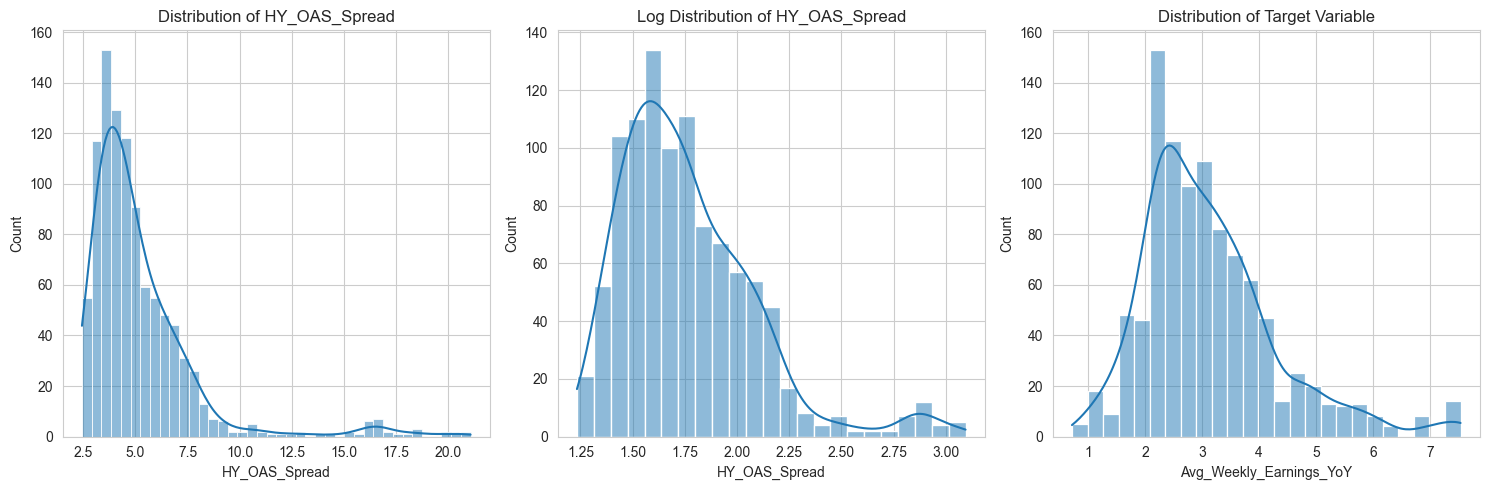

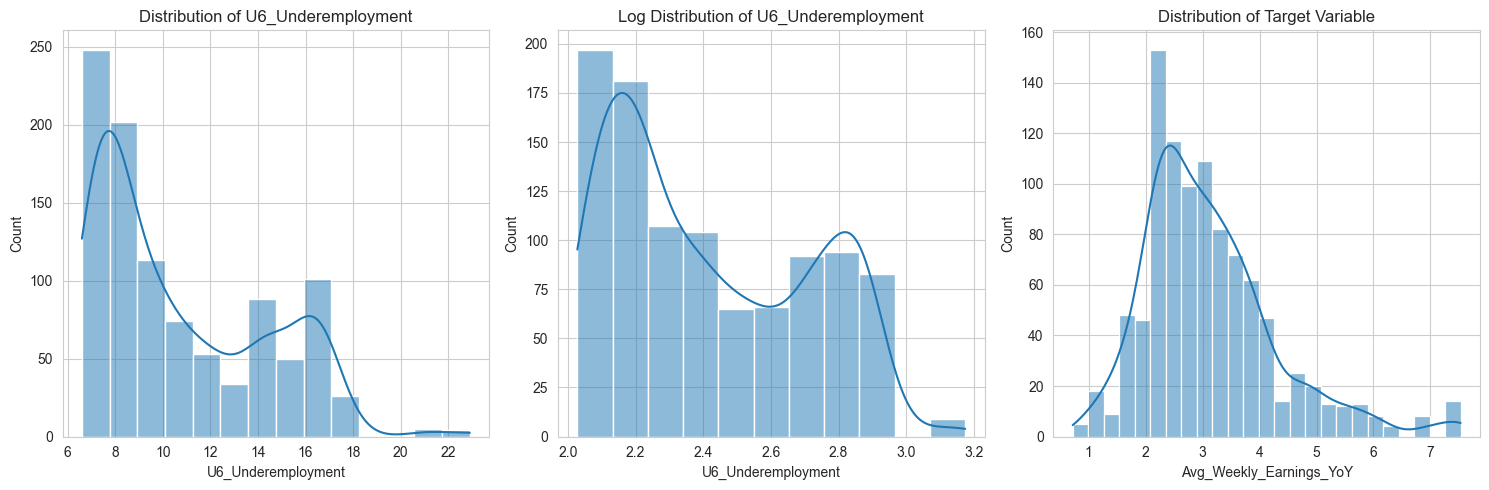

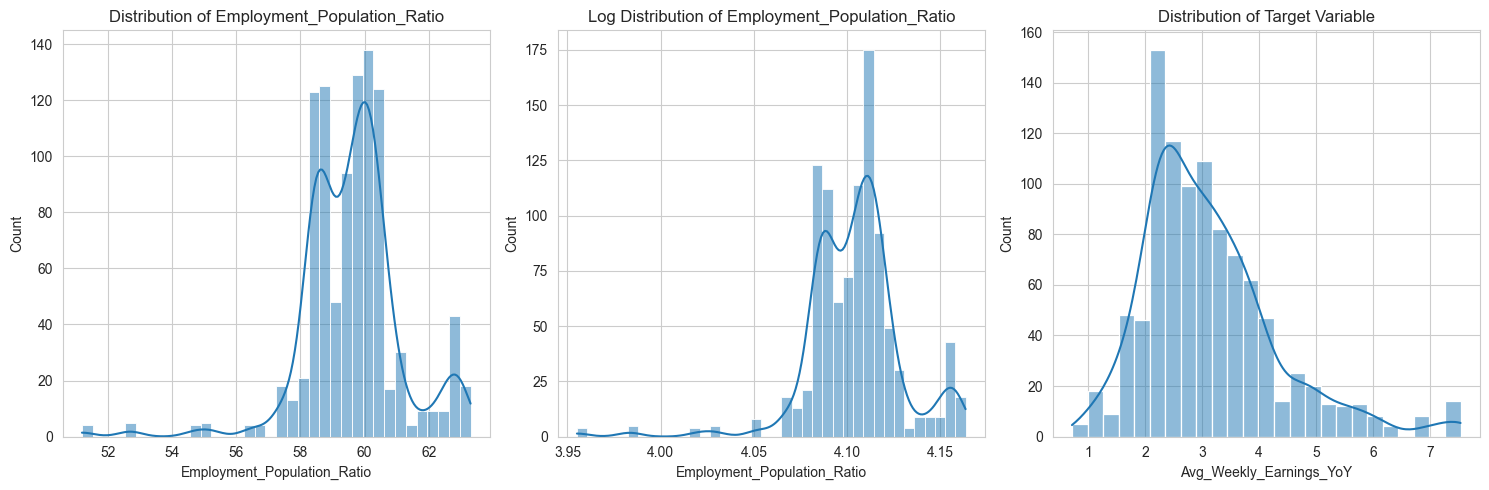

In [16]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================
from matplotlib import axes

most_important_features: list[str] = ['Payroll_Change_4w', 'Activity_Momentum', 'Core_PCE_YoY', 'JOLTS_UE_Ratio', 'Personal_Savings_Rate', 'Labor_Force_Participation', 'Sahm_Indicator', 'HY_OAS_Spread', 'U6_Underemployment', 'Employment_Population_Ratio']
  

def plot_feature_distributions(df, feature, target='Avg_Weekly_Earnings_YoY'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    sns.histplot(df[feature], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {feature}')
    log_feature = np.log1p(df[feature])  # log-transform to handle skewness
    sns.histplot(log_feature, kde=True, ax=axes[1])
    axes[1].set_title(f'Log Distribution of {feature}')

    sns.histplot(df[target], kde=True, ax=axes[2])
    axes[2].set_title('Distribution of Target Variable')

    plt.tight_layout()
    plt.show()

for feature in most_important_features:
    plot_feature_distributions(df, feature)


In [17]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================
all_cols = [col for col in df.columns if col not in ('date')]
def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR


for col in all_cols:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

Unemployment_Rate: 9 outliers (0.9%)
U6_Underemployment: 0 outliers (0.0%)
Nonfarm_Payrolls: 0 outliers (0.0%)
JOLTS_Quits: 0 outliers (0.0%)
Employment_Population_Ratio: 53 outliers (5.3%)
Part_Time_Economic_Reasons: 0 outliers (0.0%)
Labor_Force_Participation: 13 outliers (1.3%)
Initial_Jobless_Claims: 65 outliers (6.5%)
JOLTS_UE_Ratio: 0 outliers (0.0%)
Sahm_Indicator: 139 outliers (13.9%)
Payroll_Change_4w: 100 outliers (10.0%)
Industrial_Production: 95 outliers (9.5%)
Capacity_Utilization: 82 outliers (8.2%)
Retail_Sales: 0 outliers (0.0%)
Leading_Index_CB: 153 outliers (15.3%)
Activity_Momentum: 108 outliers (10.8%)
CPI_YoY: 91 outliers (9.1%)
Core_PCE_YoY: 81 outliers (8.1%)
Inflation_Momentum: 70 outliers (7.0%)
Real_FFR_PCE: 61 outliers (6.1%)
Taylor_Gap: 52 outliers (5.2%)
Treasury_10Y: 0 outliers (0.0%)
HY_OAS_Spread: 45 outliers (4.5%)
Chicago_Fed_Financial_Conditions: 103 outliers (10.3%)
Flag_Curve_Inverted_10Y2Y: 122 outliers (12.2%)
Personal_Savings_Rate: 121 outliers (

**Outlier strategy:** Keep 


This outliers occur likely during times of economic shock, (2008, COVID) and thus do not represent unreleastic or unrepresentative data. Another intuition that backs up this strategy is that outliers will likely move with one another, in that if one feature experiences a period of outlier behavior, odds are that other columns are also exhibiting such behavior. This is due to the naeture of economic response and time-series data.

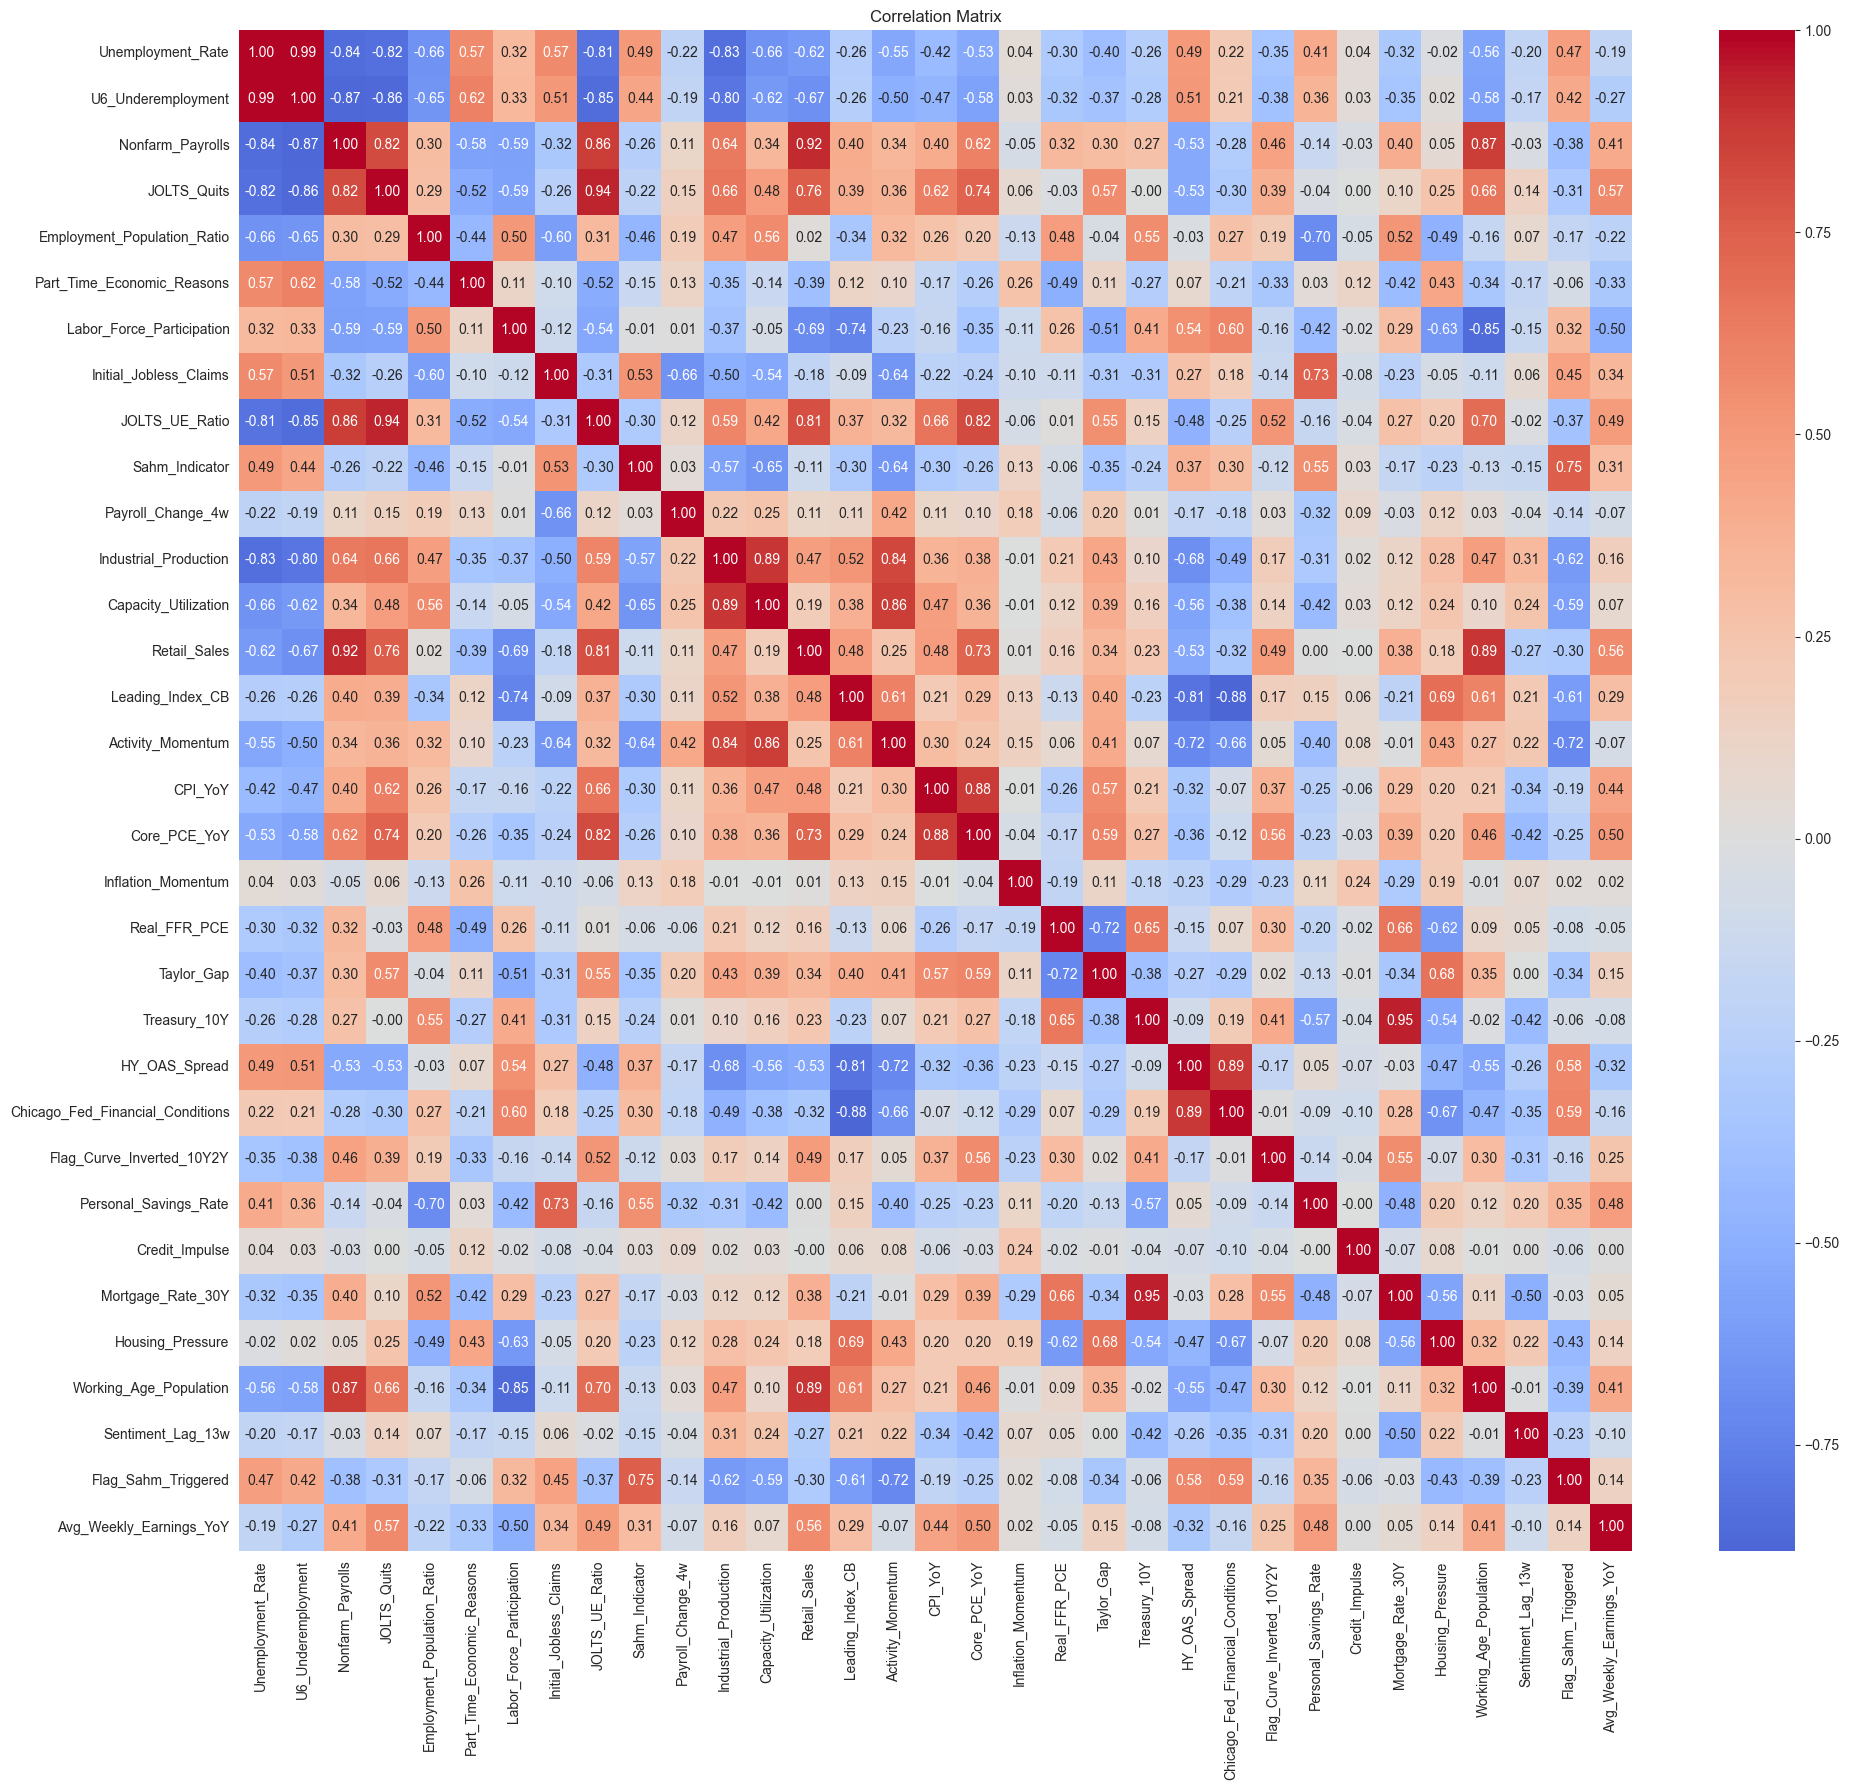

In [18]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ('year', 'Covid_Flag')]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [19]:
# get most highly correlated features with the target variable (positive or negative)

target_correlation = corr_matrix['Avg_Weekly_Earnings_YoY'].drop('Avg_Weekly_Earnings_YoY')
most_postive_corr = target_correlation.sort_values(ascending=False).head(5)
most_negative_corr = target_correlation.sort_values().head(5)
print('Top 5 most positively correlated features with target:')
print(most_postive_corr)
print('\nTop 5 most negatively correlated features with target:')
print(most_negative_corr)


Top 5 most positively correlated features with target:
JOLTS_Quits              0.569745
Retail_Sales             0.563689
Core_PCE_YoY             0.502109
JOLTS_UE_Ratio           0.490030
Personal_Savings_Rate    0.479776
Name: Avg_Weekly_Earnings_YoY, dtype: float64

Top 5 most negatively correlated features with target:
Labor_Force_Participation     -0.503299
Part_Time_Economic_Reasons    -0.329841
HY_OAS_Spread                 -0.318806
U6_Underemployment            -0.271417
Employment_Population_Ratio   -0.221899
Name: Avg_Weekly_Earnings_YoY, dtype: float64


### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

  My target variable is normally distributed, it does not require trimming or transformation. 

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   Top 5 most positively correlated features with target:
-   JOLTS_Quits              0.569745
-   Retail_Sales             0.563689
-   Core_PCE_YoY             0.502109
-   JOLTS_UE_Ratio           0.490030
-   Personal_Savings_Rate    0.479776
   

   Top 5 most negatively correlated features with target:
-   Labor_Force_Participation     -0.503299
-   Part_Time_Economic_Reasons    -0.329841
-   HY_OAS_Spread                 -0.318806
-   U6_Underemployment            -0.271417
-   Employment_Population_Ratio   -0.221899

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   Covid era measurements likely represent most of the outliers, I will include a dummy variable during the COVID years such that my model can interpret these results as unique time periods.

In [20]:
# ── Swap non-stationary levels for stationary alternatives ────────────
STATIONARY_SWAPS: dict[str, str] = {
    "Retail_Sales":              "Activity_Momentum",       # composite z-score includes retail
    "JOLTS_Quits":               "Payroll_Change_4w",       # labor momentum, already differenced
    "Part_Time_Economic_Reasons": "Sahm_Indicator",         # labor slack, already a spread
}

most_important_features = list(most_postive_corr.index) + list(most_negative_corr.index)
most_important_features = [
    STATIONARY_SWAPS.get(f, f) for f in most_important_features
]

print("Most important features based on correlation with target:")
print(most_important_features)

Most important features based on correlation with target:
['Payroll_Change_4w', 'Activity_Momentum', 'Core_PCE_YoY', 'JOLTS_UE_Ratio', 'Personal_Savings_Rate', 'Labor_Force_Participation', 'Sahm_Indicator', 'HY_OAS_Spread', 'U6_Underemployment', 'Employment_Population_Ratio']


**Data Quality Summary**

My dataset has **N = 998** observations and **M = 36** features.

**Missing data:** 0% of cells are missing.

**Outliers:** I identified minimal outliers using [Tukey Fences / IQR / visual inspection]. I will handle them by keeping them since they will be accompanied by the COVID flag.

**Target variable:** Avg_Weekly_Earnings_YoY exhibits a normal distribution with a slight rightward skew. 

**Key finding from EDA:** The highly correlated columns, COVID era outliers, distribution of key variables that may need transformation.

---

## Part 3: Modeling

### 3.1 Train/Test Split / 2 seperate for checks

In [21]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================
def train_test_split_temporal(df, features, target):
    X = df[features]
    y = df[target]

    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    split_date = df['date'].iloc[split_idx]
    print(f'Train: {X_train.shape[0]} samples (up to {split_date})')
    print(f'Test:  {X_test.shape[0]} samples (after {split_date})')

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = train_test_split_temporal(df, most_important_features, 'Avg_Weekly_Earnings_YoY')


Train: 798 samples (up to 2022-06-17)
Test:  200 samples (after 2022-06-17)


In [22]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================

def build_model1():
    from sklearn.linear_model import LinearRegression
    model_1 = LinearRegression()
    return model_1

model_1 = build_model1()
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

def build_model2():
    from sklearn.linear_model import Ridge
    model_2 = Ridge(alpha=1.0, max_iter=1000, random_state=RANDOM_STATE)
    return model_2

model_2 = build_model2()
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

# ========

print(f'Linear Regression RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'Linear Regression MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'Linear Regression R2:   {r2_score(y_test, y_pred_1):.4f}')

print(f'Ridge RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'Ridge MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'Ridge R2:   {r2_score(y_test, y_pred_2):.4f}')

Linear Regression RMSE: 0.4795
Linear Regression MAE:  0.3673
Linear Regression R2:   -0.3388
Ridge RMSE: 0.4847
Ridge MAE:  0.3733
Ridge R2:   -0.3679
